# Hepatocyte State Identification and Clinical Context
This notebook presents a focused four-figure story using the selected configuration:

- `track_strategy = exp_decay`
- `bin_size = 500,000`
- `metric = spearman_r_linear_resid`

The workflow uses mutation-burden-adjusted score-based analyses as primary, with label-based analyses as sensitivity checks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'outputs' / 'experiments').exists():
    ROOT = ROOT.parent

RANKINGS_PATH = ROOT / 'outputs/experiments/lihc_foxa2_top4_all_samples_per_sample_merged/validation_score_rankings.csv'
RESULTS_LONG_PATH = ROOT / 'outputs/experiments/lihc_foxa2_top4_all_samples_per_sample_merged/results.csv'
CLINICAL_PATH = ROOT / 'outputs/experiments/lihc_foxa2_top4_all_samples_per_sample_merged/labels_with_clinical_counts_all_lihc_deduped_from_results_labelled_only.csv'

FIG_DIR = ROOT / 'outputs/thesis/02_hepatocyte_clinical_associations/figures'
SUMMARY_DIR = ROOT / 'outputs/thesis/02_hepatocyte_clinical_associations/data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_TRACK = 'exp_decay'
PRIMARY_BIN = 500000.0
PRIMARY_METRIC = 'spearman_r_linear_resid'
PRIMARY_CONFIG = f'track_strategy={PRIMARY_TRACK}|bin_size={PRIMARY_BIN}'

rankings = pd.read_csv(RANKINGS_PATH)
long_results = pd.read_csv(RESULTS_LONG_PATH)
clinical = pd.read_csv(CLINICAL_PATH)

selected = rankings[
    (rankings['config_id'] == PRIMARY_CONFIG)
    & (rankings['scoring_system'] == PRIMARY_METRIC)
].copy()
selected['sample_id_short'] = selected['sample'].astype(str).str.slice(0, 15)
state_map = {
    'foxa2_normal_pos': 'FOXA2 normal-like',
    'foxa2_abnormal_zero': 'FOXA2 abnormal-like',
}
selected['assigned_state'] = selected['best_cell_state'].map(state_map).fillna(selected['best_cell_state'])

mb = long_results[['sample_id', 'mutations_post_downsample']].copy()
mb['sample_id'] = mb['sample_id'].astype(str)
mb = mb.rename(columns={'sample_id': 'sample', 'mutations_post_downsample': 'mutation_burden'})
mb = mb.drop_duplicates(subset=['sample'])

selected = selected.merge(mb, on='sample', how='left')
clinical['sample_id'] = clinical['sample_id'].astype(str).str.strip()
analysis_df = selected.merge(clinical, left_on='sample_id_short', right_on='sample_id', how='left')


def adjust_score_for_mutation_burden(frame: pd.DataFrame, score_col: str, mb_col: str = 'mutation_burden') -> pd.Series:
    d = frame[[score_col, mb_col]].copy()
    d[score_col] = pd.to_numeric(d[score_col], errors='coerce')
    d[mb_col] = pd.to_numeric(d[mb_col], errors='coerce')
    valid = d.dropna().index
    out = pd.Series(np.nan, index=frame.index, dtype=float)
    if len(valid) < 3:
        return out
    x = np.log10(d.loc[valid, mb_col].to_numpy(dtype=float) + 1.0)
    y = d.loc[valid, score_col].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    out.loc[valid] = y - yhat + y.mean()
    return out

analysis_df['score_abnormal_adj_mutburden'] = adjust_score_for_mutation_burden(analysis_df, 'score_foxa2_abnormal_zero')
analysis_df['score_normal_adj_mutburden'] = adjust_score_for_mutation_burden(analysis_df, 'score_foxa2_normal_pos')

clinical_deduped = not clinical['sample_id'].duplicated().any()
selected_unique = analysis_df['sample'].nunique() == len(analysis_df)
print('Clinical labels deduped:', clinical_deduped)
print('Selected rows unique per sample:', selected_unique)
print('Plot 3 score uses mutation-burden adjustment:', 'score_abnormal_adj_mutburden')
print('Plot 4 score uses mutation-burden adjustment:', 'score_normal_adj_mutburden')

print('Primary setup:', PRIMARY_CONFIG, PRIMARY_METRIC)
print('Selected samples:', analysis_df['sample'].nunique())

Clinical labels deduped: True
Selected rows unique per sample: True
Plot 3 score uses mutation-burden adjustment: score_abnormal_adj_mutburden
Plot 4 score uses mutation-burden adjustment: score_normal_adj_mutburden
Primary setup: track_strategy=exp_decay|bin_size=500000.0 spearman_r_linear_resid
Selected samples: 152


## 1) FOXA2 State Distribution

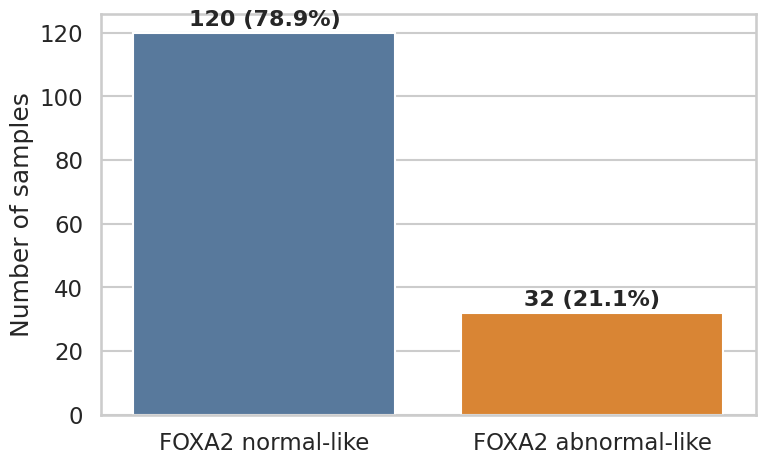

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/02_hepatocyte_clinical_associations/figures/01_state_distribution_selected_setup.png


In [2]:
state_counts = analysis_df['assigned_state'].value_counts().rename_axis('assigned_state').reset_index(name='n_samples')
state_counts['pct'] = 100.0 * state_counts['n_samples'] / state_counts['n_samples'].sum()
order = ['FOXA2 normal-like', 'FOXA2 abnormal-like']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=state_counts, x='assigned_state', y='n_samples', hue='assigned_state', order=order, hue_order=order, palette=['#4C78A8', '#F58518'], legend=False, ax=ax)
for i, row in state_counts.set_index('assigned_state').reindex(order).reset_index().iterrows():
    if pd.notna(row['n_samples']):
        ax.text(i, row['n_samples'] + 1, f"{int(row['n_samples'])} ({row['pct']:.1f}%)", ha='center', va='bottom', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of samples')
plt.tight_layout()
fig_path = FIG_DIR / '01_state_distribution_selected_setup.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', fig_path)
state_counts.to_csv(SUMMARY_DIR / '01_state_distribution_best_setup.csv', index=False)


## 2) Label-Based Sensitivity

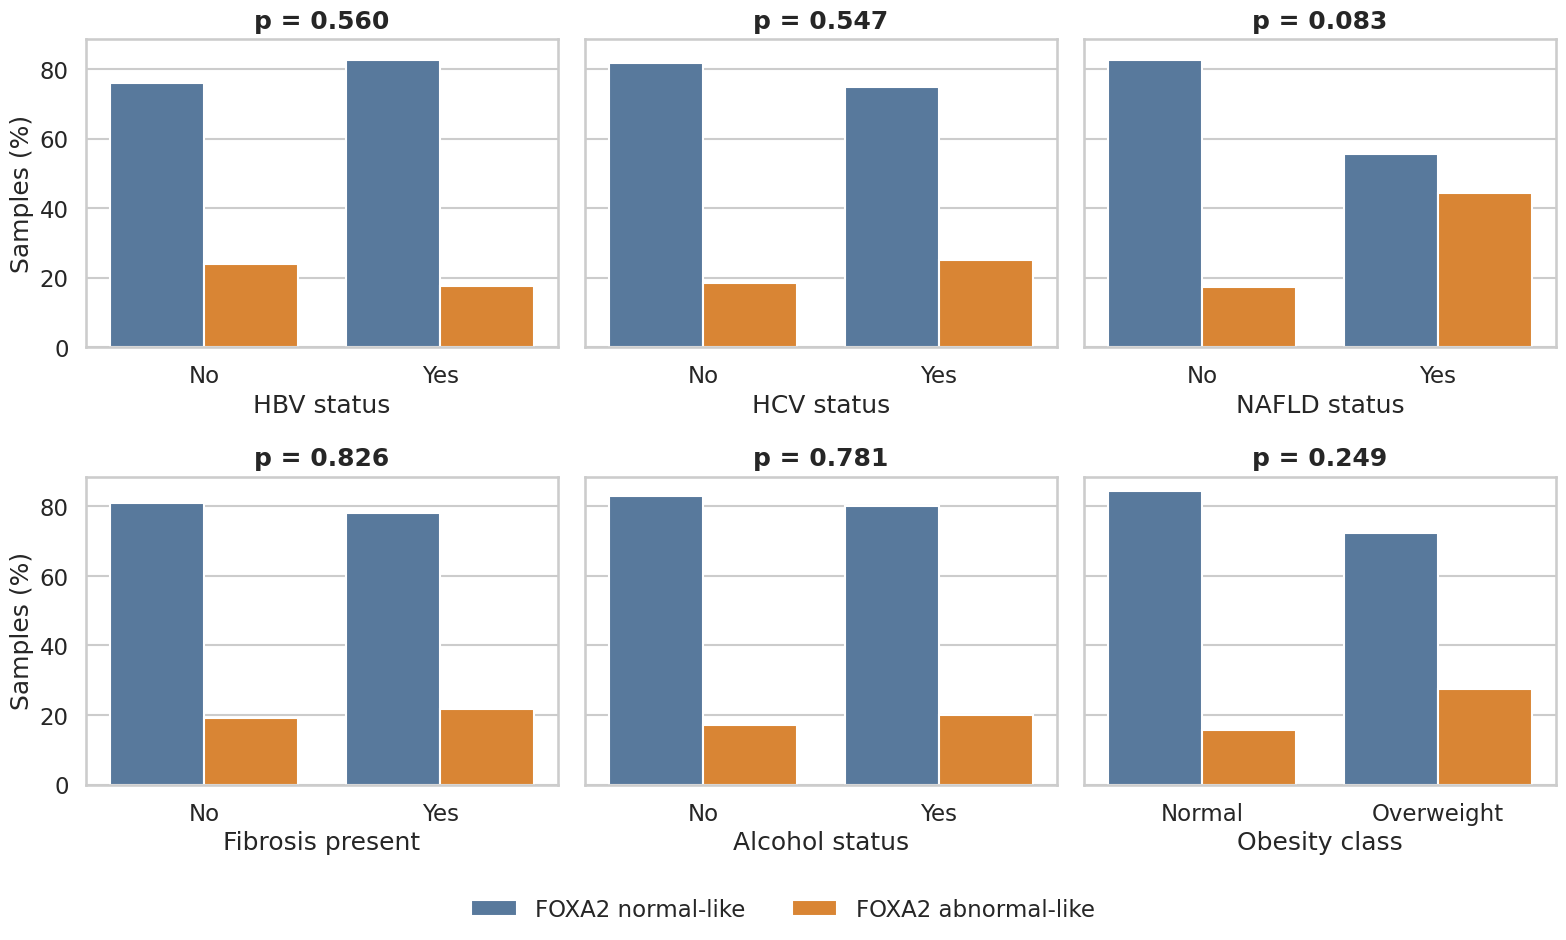

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/02_hepatocyte_clinical_associations/figures/02_label_sensitivity_state_composition.png


In [3]:
label_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
    ('nafld_status', ['no', 'yes'], ['No', 'Yes'], 'NAFLD status'),
    ('fibrosis_present', ['no', 'yes'], ['No', 'Yes'], 'Fibrosis present'),
    ('alcohol_status', ['no', 'yes'], ['No', 'Yes'], 'Alcohol status'),
    ('obesity_class', ['normal', 'overweight'], ['Normal', 'Overweight'], 'Obesity class'),
]

rows = []
plot_rows = []

for var, levels, tick_labels, _ in label_specs:
    sub = analysis_df[[var, 'assigned_state']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    if sub.empty or sub[var].nunique() < 2:
        continue

    tab = pd.crosstab(sub[var], sub['assigned_state'])
    if tab.shape == (2, 2):
        _, p_value = fisher_exact(tab)
        test_type = 'fisher_exact'
    else:
        _, p_value, _, _ = chi2_contingency(tab)
        test_type = 'chi2'

    prop = pd.crosstab(sub[var], sub['assigned_state'], normalize='index')
    a0 = float(prop.loc[levels[0], 'FOXA2 abnormal-like']) if (levels[0] in prop.index and 'FOXA2 abnormal-like' in prop.columns) else np.nan
    a1 = float(prop.loc[levels[1], 'FOXA2 abnormal-like']) if (levels[1] in prop.index and 'FOXA2 abnormal-like' in prop.columns) else np.nan

    rows.append({
        'clinical_variable': var,
        'n_total': int(len(sub)),
        'test_type': test_type,
        'p_value': float(p_value),
        'abnormal_fraction_group0': a0,
        'abnormal_fraction_group1': a1,
        'abnormal_fraction_group1_minus_group0': a1 - a0 if np.isfinite(a0) and np.isfinite(a1) else np.nan,
    })

    ptab = pd.crosstab(sub[var], sub['assigned_state'], normalize='index').reset_index()
    long = ptab.melt(id_vars=var, var_name='assigned_state', value_name='fraction')
    long['clinical_variable'] = var
    long['group_order'] = long[var].map({levels[0]: 0, levels[1]: 1})
    long['group_label'] = long[var].map({levels[0]: tick_labels[0], levels[1]: tick_labels[1]})
    plot_rows.append(long)

label_summary = pd.DataFrame(rows).sort_values('p_value')
label_summary.to_csv(SUMMARY_DIR / '02_label_based_sensitivity_summary_best_setup.csv', index=False)

plot_df = pd.concat(plot_rows, ignore_index=True)
plot_df['pct'] = 100.0 * plot_df['fraction']

def _fmt_p(p):
    if pd.isna(p):
        return 'p = n/a'
    if float(p) < 0.001:
        return 'p < 0.001'
    return f"p = {float(p):.3f}"

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for i, (ax, (var, levels, tick_labels, display_name)) in enumerate(zip(axes, label_specs)):
    sub = plot_df[plot_df['clinical_variable'] == var].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    sns.barplot(
        data=sub,
        x='group_order',
        y='pct',
        hue='assigned_state',
        hue_order=['FOXA2 normal-like', 'FOXA2 abnormal-like'],
        palette=['#4C78A8', '#F58518'],
        ax=ax,
    )
    p = label_summary.loc[label_summary['clinical_variable'] == var, 'p_value']
    ptxt = _fmt_p(float(p.iloc[0])) if len(p) else 'p = n/a'
    ax.text(0.5, 1.02, ptxt, transform=ax.transAxes, va='bottom', ha='center', fontsize=18, fontweight='bold', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.75, 'pad': 2.5}, clip_on=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel(display_name)
    if i % 3 == 0:
        ax.set_ylabel('Samples (%)')
    else:
        ax.set_ylabel('')

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
fig.legend(handles, labels, title=None, loc='lower center', bbox_to_anchor=(0.5, -0.01), ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
fig_path = FIG_DIR / '02_label_sensitivity_state_composition.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', fig_path)


## 3) Primary Score-Based Clinical Associations (Adjusted)

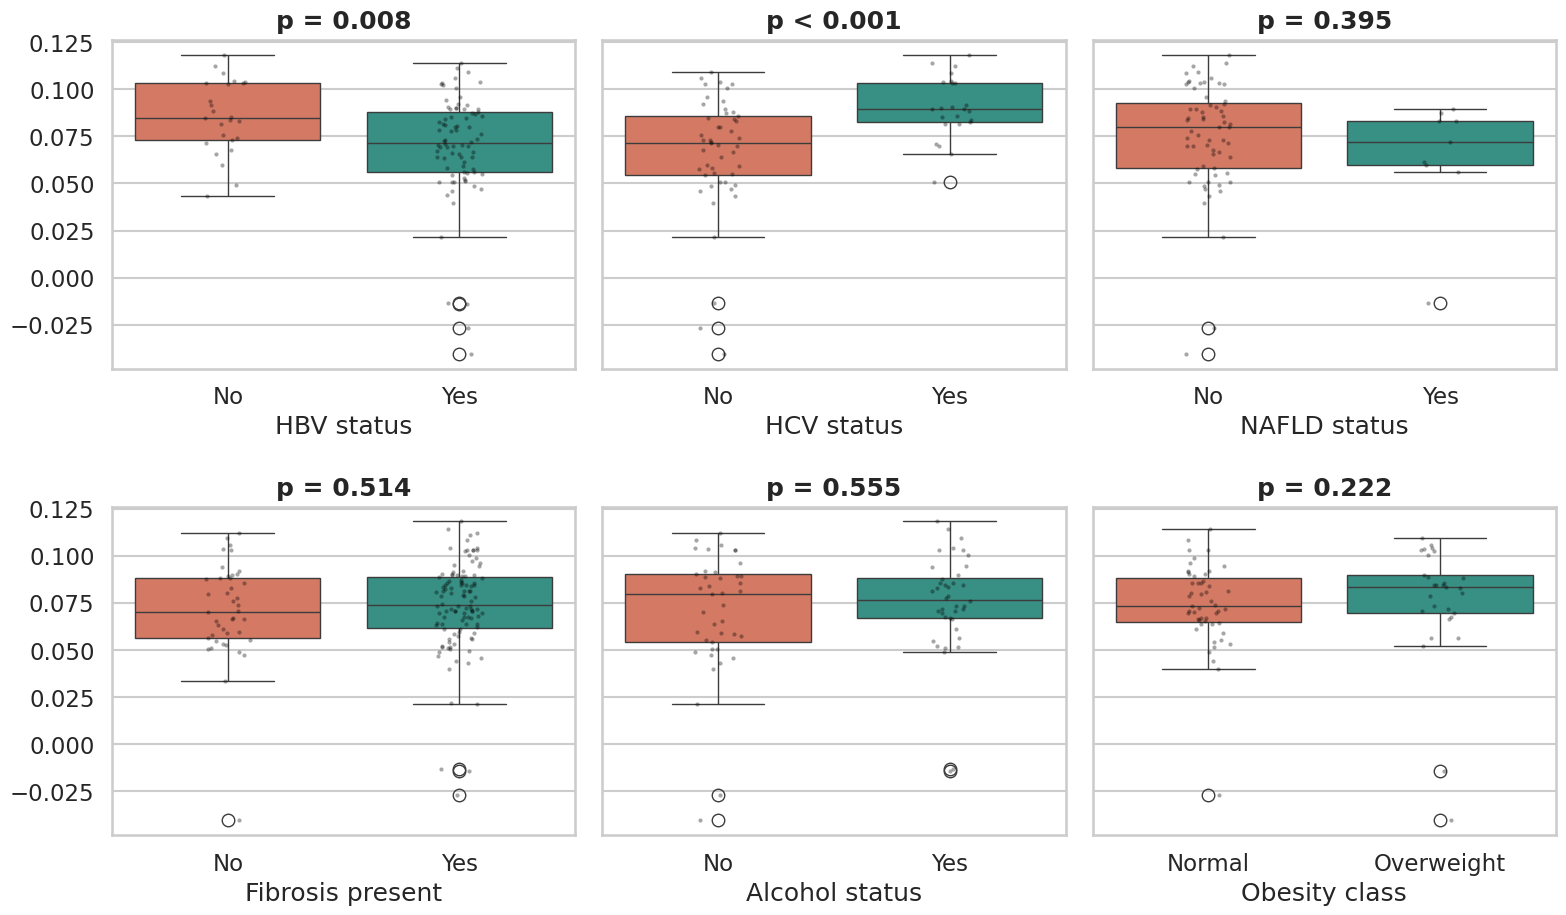

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/02_hepatocyte_clinical_associations/figures/03_clinical_boxplots_adjusted_score.png


In [4]:
score_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
    ('nafld_status', ['no', 'yes'], ['No', 'Yes'], 'NAFLD status'),
    ('fibrosis_present', ['no', 'yes'], ['No', 'Yes'], 'Fibrosis present'),
    ('alcohol_status', ['no', 'yes'], ['No', 'Yes'], 'Alcohol status'),
    ('obesity_class', ['normal', 'overweight'], ['Normal', 'Overweight'], 'Obesity class'),
]

group_palette = {'no': '#E76F51', 'yes': '#2A9D8F', 'normal': '#E76F51', 'overweight': '#2A9D8F'}

rows = []
for var, levels, _, _ in score_specs:
    sub = analysis_df[[var, 'score_abnormal_adj_mutburden']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    if sub.empty or sub[var].nunique() < 2:
        continue

    g0 = sub.loc[sub[var] == levels[0], 'score_abnormal_adj_mutburden']
    g1 = sub.loc[sub[var] == levels[1], 'score_abnormal_adj_mutburden']
    _, p_value = mannwhitneyu(g0, g1, alternative='two-sided')
    rows.append({
        'clinical_variable': var,
        'n_group0': int(len(g0)),
        'n_group1': int(len(g1)),
        'median_group0_adjusted': float(g0.median()),
        'median_group1_adjusted': float(g1.median()),
        'median_group1_minus_group0_adjusted': float(g1.median() - g0.median()),
        'p_value_mannwhitney_adjusted': float(p_value),
    })

summary4 = pd.DataFrame(rows).sort_values('p_value_mannwhitney_adjusted')

def _fmt_p(p):
    if pd.isna(p):
        return 'p = n/a'
    if float(p) < 0.001:
        return 'p < 0.001'
    return f"p = {float(p):.3f}"
summary4.to_csv(SUMMARY_DIR / '03_clinical_score_association_summary_best_setup.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for i, (ax, (var, levels, tick_labels, display_name)) in enumerate(zip(axes, score_specs)):
    sub = analysis_df[[var, 'score_abnormal_adj_mutburden']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    if sub.empty or sub[var].nunique() < 2:
        ax.set_visible(False)
        continue

    sns.boxplot(
        data=sub,
        x=var,
        y='score_abnormal_adj_mutburden',
        order=levels,
        hue=var,
        hue_order=levels,
        palette=[group_palette[l] for l in levels],
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x=var,
        y='score_abnormal_adj_mutburden',
        order=levels,
        color='black',
        alpha=0.35,
        size=3,
        ax=ax,
    )

    _, p_value = mannwhitneyu(
        sub.loc[sub[var] == levels[0], 'score_abnormal_adj_mutburden'],
        sub.loc[sub[var] == levels[1], 'score_abnormal_adj_mutburden'],
        alternative='two-sided',
    )
    ax.text(0.5, 1.02, _fmt_p(p_value), transform=ax.transAxes, va='bottom', ha='center', fontsize=18, fontweight='bold', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.75, 'pad': 2.5}, clip_on=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel(display_name)
    ax.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
fig_path = FIG_DIR / '03_clinical_boxplots_adjusted_score.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', fig_path)


## 4) Primary Score-Based Clinical Associations (Adjusted, Normal-like score)

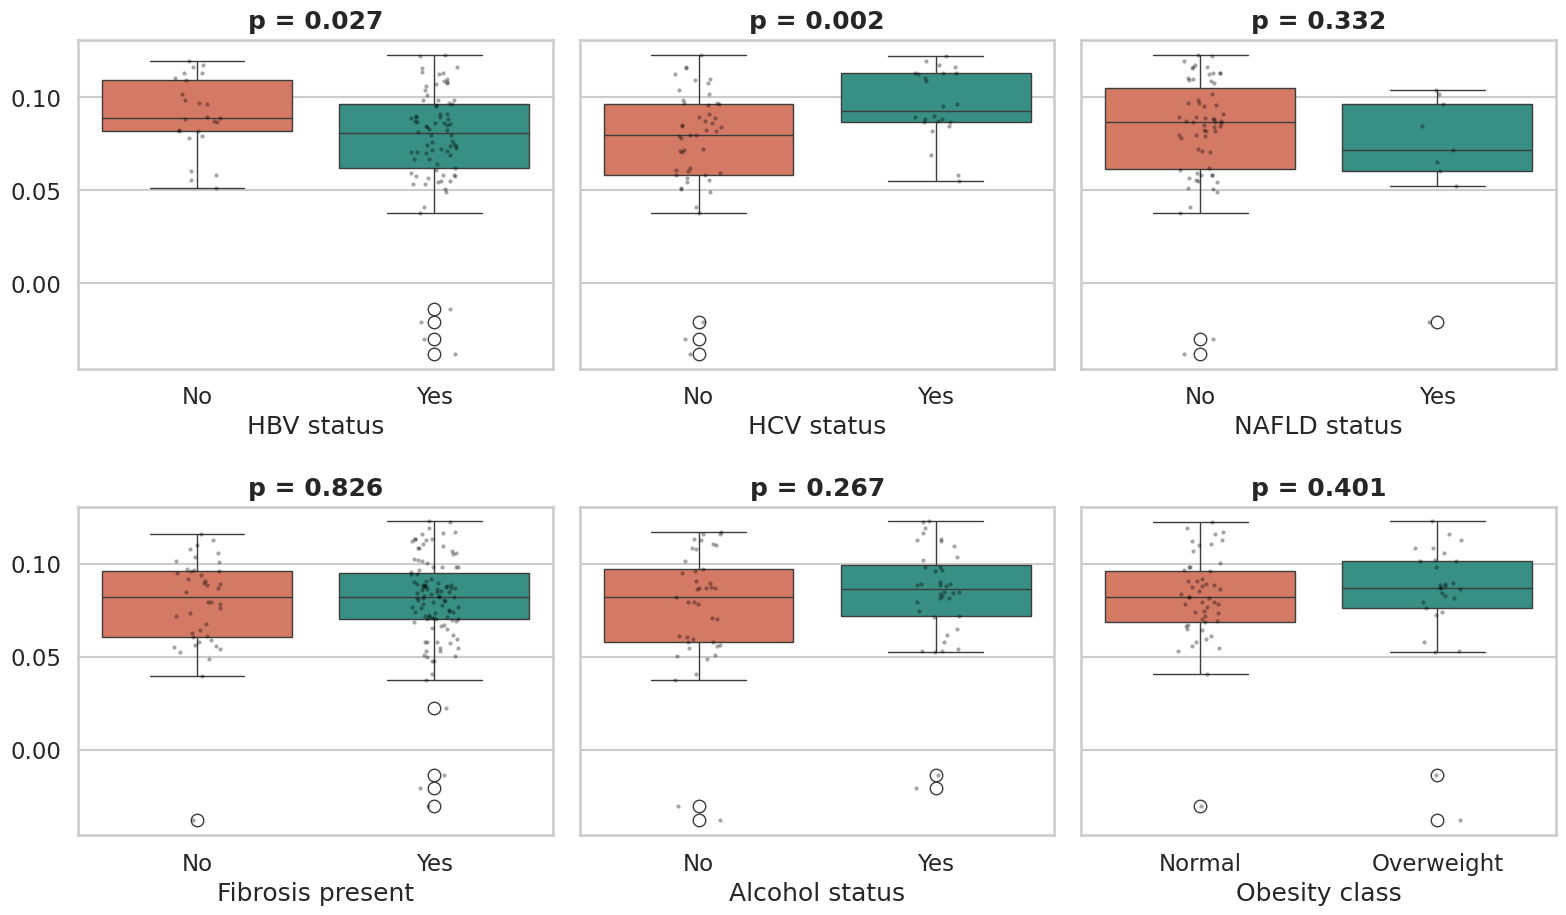

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/02_hepatocyte_clinical_associations/figures/04_clinical_boxplots_adjusted_score_normal.png


In [5]:
score_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
    ('nafld_status', ['no', 'yes'], ['No', 'Yes'], 'NAFLD status'),
    ('fibrosis_present', ['no', 'yes'], ['No', 'Yes'], 'Fibrosis present'),
    ('alcohol_status', ['no', 'yes'], ['No', 'Yes'], 'Alcohol status'),
    ('obesity_class', ['normal', 'overweight'], ['Normal', 'Overweight'], 'Obesity class'),
]

group_palette = {'no': '#E76F51', 'yes': '#2A9D8F', 'normal': '#E76F51', 'overweight': '#2A9D8F'}

rows = []
for var, levels, _, _ in score_specs:
    sub = analysis_df[[var, 'score_normal_adj_mutburden']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    if sub.empty or sub[var].nunique() < 2:
        continue

    g0 = sub.loc[sub[var] == levels[0], 'score_normal_adj_mutburden']
    g1 = sub.loc[sub[var] == levels[1], 'score_normal_adj_mutburden']
    _, p_value = mannwhitneyu(g0, g1, alternative='two-sided')
    rows.append({
        'clinical_variable': var,
        'n_group0': int(len(g0)),
        'n_group1': int(len(g1)),
        'median_group0_adjusted': float(g0.median()),
        'median_group1_adjusted': float(g1.median()),
        'median_group1_minus_group0_adjusted': float(g1.median() - g0.median()),
        'p_value_mannwhitney_adjusted': float(p_value),
    })

summary4 = pd.DataFrame(rows).sort_values('p_value_mannwhitney_adjusted')

def _fmt_p(p):
    if pd.isna(p):
        return 'p = n/a'
    if float(p) < 0.001:
        return 'p < 0.001'
    return f"p = {float(p):.3f}"
summary4.to_csv(SUMMARY_DIR / '04_clinical_score_association_normal_summary_best_setup.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for i, (ax, (var, levels, tick_labels, display_name)) in enumerate(zip(axes, score_specs)):
    sub = analysis_df[[var, 'score_normal_adj_mutburden']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    if sub.empty or sub[var].nunique() < 2:
        ax.set_visible(False)
        continue

    sns.boxplot(
        data=sub,
        x=var,
        y='score_normal_adj_mutburden',
        order=levels,
        hue=var,
        hue_order=levels,
        palette=[group_palette[l] for l in levels],
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x=var,
        y='score_normal_adj_mutburden',
        order=levels,
        color='black',
        alpha=0.35,
        size=3,
        ax=ax,
    )

    _, p_value = mannwhitneyu(
        sub.loc[sub[var] == levels[0], 'score_normal_adj_mutburden'],
        sub.loc[sub[var] == levels[1], 'score_normal_adj_mutburden'],
        alternative='two-sided',
    )
    ax.text(0.5, 1.02, _fmt_p(p_value), transform=ax.transAxes, va='bottom', ha='center', fontsize=18, fontweight='bold', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.75, 'pad': 2.5}, clip_on=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel(display_name)
    ax.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
fig_path = FIG_DIR / '04_clinical_boxplots_adjusted_score_normal.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', fig_path)


## 5) Significant Clinical Associations Across Both Tracks (Adjusted)

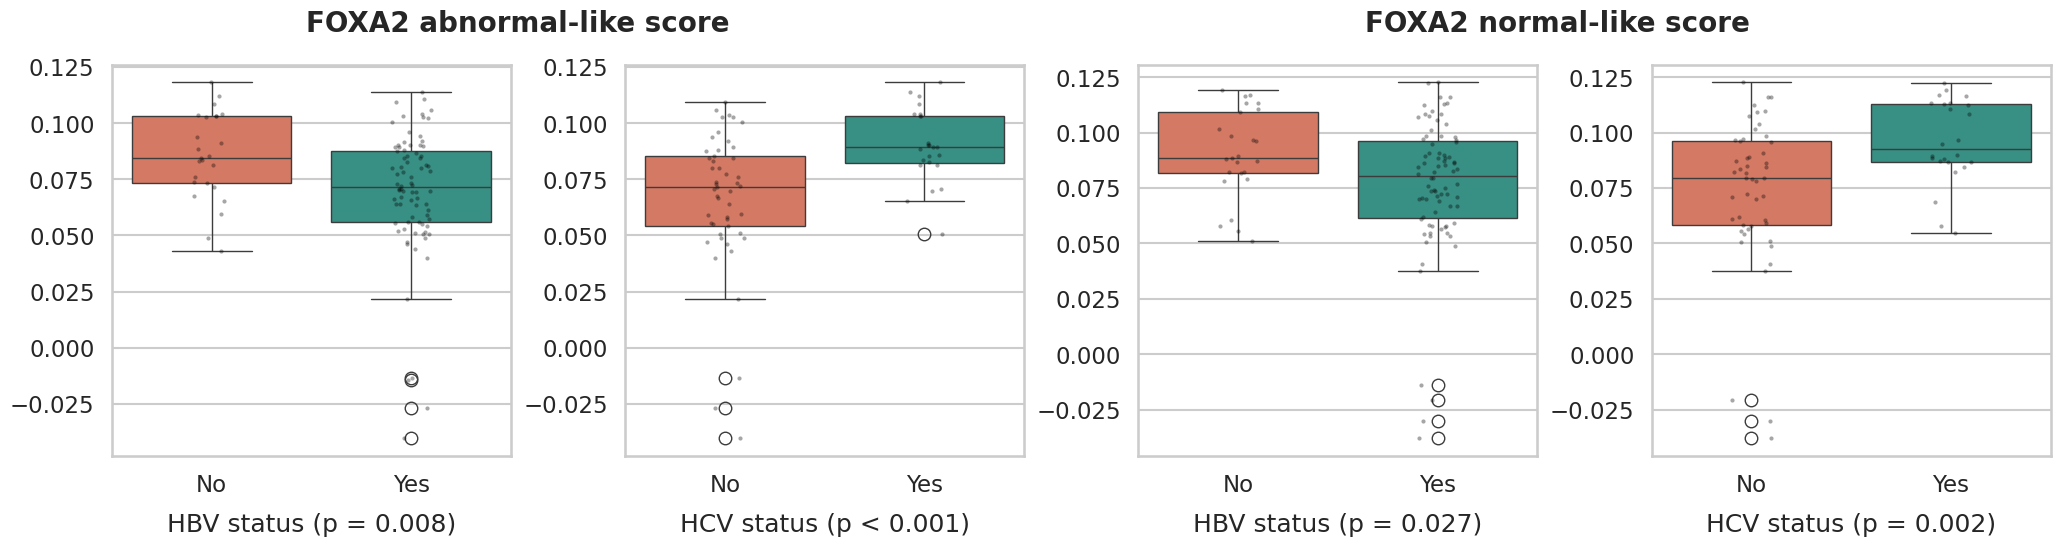

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/02_hepatocyte_clinical_associations/figures/05_significant_clinical_boxplots_both_tracks.png


In [6]:
score_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
    ('nafld_status', ['no', 'yes'], ['No', 'Yes'], 'NAFLD status'),
    ('fibrosis_present', ['no', 'yes'], ['No', 'Yes'], 'Fibrosis present'),
    ('alcohol_status', ['no', 'yes'], ['No', 'Yes'], 'Alcohol status'),
    ('obesity_class', ['normal', 'overweight'], ['Normal', 'Overweight'], 'Obesity class'),
]

var_label = {v: d for v, _, _, d in score_specs}
var_levels = {v: lv for v, lv, _, _ in score_specs}
var_ticks = {v: tk for v, _, tk, _ in score_specs}
var_order = [v for v, _, _, _ in score_specs]
group_palette = {'no': '#E76F51', 'yes': '#2A9D8F', 'normal': '#E76F51', 'overweight': '#2A9D8F'}

abn_summary = pd.read_csv(SUMMARY_DIR / '03_clinical_score_association_summary_best_setup.csv')
norm_summary = pd.read_csv(SUMMARY_DIR / '04_clinical_score_association_normal_summary_best_setup.csv')

abn_sig = abn_summary[abn_summary['p_value_mannwhitney_adjusted'] < 0.05].copy()
norm_sig = norm_summary[norm_summary['p_value_mannwhitney_adjusted'] < 0.05].copy()

abn_sig['track'] = 'Abnormal-like score'
norm_sig['track'] = 'Normal-like score'
sig_table = pd.concat([abn_sig, norm_sig], ignore_index=True)
if not sig_table.empty:
    sig_table = sig_table.sort_values(['track', 'p_value_mannwhitney_adjusted', 'clinical_variable'])

sig_table.to_csv(SUMMARY_DIR / '05_significant_clinical_results_both_tracks_best_setup.csv', index=False)

abn_vars = [v for v in var_order if v in set(abn_sig['clinical_variable'])]
norm_vars = [v for v in var_order if v in set(norm_sig['clinical_variable'])]

panels = [('Abnormal-like score', v, 'score_abnormal_adj_mutburden', abn_summary) for v in abn_vars] +          [('Normal-like score', v, 'score_normal_adj_mutburden', norm_summary) for v in norm_vars]

n_cols = max(len(panels), 1)
fig, axes = plt.subplots(1, n_cols, figsize=(5.2 * n_cols, 5.6), sharey=False)
axes = np.atleast_1d(axes)


def _fmt_p(p):
    if pd.isna(p):
        return 'p = n/a'
    if float(p) < 0.001:
        return 'p < 0.001'
    return f"p = {float(p):.3f}"

if len(panels) == 0:
    for ax in axes:
        ax.set_visible(False)
else:
    for ax, (track_label, var, score_col, summary_df) in zip(axes, panels):
        levels = var_levels[var]
        tick_labels = var_ticks[var]

        sub = analysis_df[[var, score_col]].dropna().copy()
        sub[var] = sub[var].astype(str).str.strip().str.lower()
        sub = sub[sub[var].isin(levels)]

        sns.boxplot(
            data=sub,
            x=var,
            y=score_col,
            order=levels,
            hue=var,
            hue_order=levels,
            palette=[group_palette[l] for l in levels],
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=sub,
            x=var,
            y=score_col,
            order=levels,
            color='black',
            alpha=0.35,
            size=3,
            ax=ax,
        )

        p = summary_df.loc[summary_df['clinical_variable'] == var, 'p_value_mannwhitney_adjusted']
        ptxt = _fmt_p(float(p.iloc[0])) if len(p) else 'p = n/a'
        ax.set_xticks([0, 1])
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel(f"{var_label[var]} ({ptxt})", labelpad=12)
        ax.set_ylabel('')

if len(abn_vars) > 0:
    fig.text(0.25, 0.99, 'FOXA2 abnormal-like score', ha='center', va='top', fontsize=20, fontweight='bold')
if len(norm_vars) > 0:
    fig.text(0.75, 0.99, 'FOXA2 normal-like score', ha='center', va='top', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig_path = FIG_DIR / '05_significant_clinical_boxplots_both_tracks.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', fig_path)


## Figure Manifest

In [7]:
figs = sorted(FIG_DIR.glob('*.png'))
for f in figs:
    print(f.name)
print(f'\nTotal figures: {len(figs)}')

summary_files = sorted(SUMMARY_DIR.glob('*.csv'))
for f in summary_files:
    print(f.name)
print(f'\nTotal summary tables: {len(summary_files)}')


01_state_distribution_selected_setup.png
02_label_sensitivity_state_composition.png
03_clinical_boxplots_adjusted_score.png
04_clinical_boxplots_adjusted_score_normal.png
05_significant_clinical_boxplots_both_tracks.png

Total figures: 5
01_state_distribution_best_setup.csv
02_label_based_sensitivity_summary_best_setup.csv
03_clinical_score_association_summary_best_setup.csv
04_clinical_score_association_normal_summary_best_setup.csv
05_significant_clinical_results_both_tracks_best_setup.csv

Total summary tables: 5
